# Nyhedsørkener i Region Syddanmark — Reproduktion af rapporten

Denne notebook reproducerer tallene i `news_deserts_full.tex` (rapportens §4–§4.5).

**Kilder:**
- `news_desert_coding_template_prefilled.xlsx` — den udfyldte avis-kommune-kortlægning
  (60 rækker, 34 unikke aviser, 22 dækkede kommuner)
- `dk_municipalities.csv` — alle 98 kommuner med population
- `kommuner.geojson` — kommunepolygoner fra Dataforsyningen
- `socioeconomic_data.csv` — gns. indkomst (INDKP101), andel m. videregående
  uddannelse (HFUDD10), valgdeltagelse KV21

**Studieområde:** 23 kommuner i Region Syddanmark (Horsens er kode 615 og er i
`dk_municipalities.csv` allerede tagget som Syddanmark fordi den falder i JFM-footprint).

**Hovedforskelle fra `analyse.ipynb`:**
1. Læser den *udfyldte* skabelon (ikke den tomme på 5 rækker)
2. Filtrerer til 23 studie-kommuner (ikke alle 98)
3. Bruger både Queen *og* KNN-4 vægte — KNN-4 fra projicerede centroider (EPSG:25832)
4. Rapporterer Spearman ved siden af Pearson

## 0. Imports og konfiguration

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from libpysal.weights import Queen, KNN
from esda.moran import Moran, Moran_Local
from scipy.stats import spearmanr, pearsonr

# Stier — alle filer ligger i samme mappe som notebooken
GEOJSON_PATH = "kommuner.geojson"
CODING_XLSX  = "news_desert_coding_template_prefilled.xlsx"   # ← den UDFYLDTE
MUNI_CSV     = "dk_municipalities.csv"
SOCIO_CSV    = "socioeconomic_data.csv"

# Reproducerbarhed for permutations-baserede p-værdier
RANDOM_SEED = 42

%matplotlib inline
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'
print("✓ Imports klar")

✓ Imports klar


## 1. Indlæs kommunedata (alle 98)

`dk_municipalities.csv` indeholder navn, region og befolkning per kommune. Bemærk at
Horsens (615) er tagget `region = "Syddanmark"` i denne fil, fordi rapporten studerer
JFM's coverage-footprint og inkluderer Horsens.

In [2]:
muni = pd.read_csv(MUNI_CSV).rename(columns={"population_approx": "population"})
print(f"Antal kommuner: {len(muni)}")
print(f"Samlet befolkning: {muni['population'].sum():,}")
print(muni.groupby('region')['population'].agg(['count', 'sum']).rename(
    columns={'count': 'kommuner', 'sum': 'befolkning'}))

Antal kommuner: 98
Samlet befolkning: 6,025,511
             kommuner  befolkning
region                           
Hovedstaden        29     1947120
Midtjylland        20     1346371
Nordjylland         9      531198
Sjælland           17      858102
Syddanmark         23     1342720


## 2. Indlæs avisdata fra den udfyldte skabelon

Forventede tal (jf. rapport §4.1):
- 60 newspaper-to-municipality mapping-rækker
- 34 unikke aviser
- 22 dækkede kommuner inden for studieområdet

In [3]:
raw = pd.read_excel(CODING_XLSX, sheet_name="newspaper_municipality_map")
raw = raw.dropna(subset=["kommune_kode", "newspaper_id"])
raw["kommune_kode"] = raw["kommune_kode"].astype(int)

print(f"Mapping-rækker:    {len(raw)}")
print(f"Unikke aviser:     {raw['newspaper_id'].nunique()}")
print(f"Dækkede kommuner:  {raw['kommune_kode'].nunique()}")

# Publisher-koncentration (rapport §4.1)
pub_counts = raw['publisher'].value_counts()
print("\nPublisher-fordeling (rækker):")
print(pub_counts)

# Publisher-strengen i den udfyldte skabelon er "JFM" (ikke "Jysk Fynske Medier")
JFM_LABEL = "JFM"
jfm_titles = raw.loc[raw['publisher']==JFM_LABEL, 'newspaper_id'].nunique()
total_titles = raw['newspaper_id'].nunique()
print(f"\nJFM andel af titler: {jfm_titles}/{total_titles} = {jfm_titles/total_titles:.1%}")
print(f"JFM andel af rækker: {pub_counts.get(JFM_LABEL,0)}/{len(raw)} = "
      f"{pub_counts.get(JFM_LABEL,0)/len(raw):.1%}")

Mapping-rækker:    60
Unikke aviser:     34
Dækkede kommuner:  22

Publisher-fordeling (rækker):
publisher
JFM                           51
BDN/Deutscher Presseverein     4
Uafhængig                      4
Ukendt                         1
Name: count, dtype: int64

JFM andel af titler: 31/34 = 91.2%
JFM andel af rækker: 51/60 = 85.0%


## 3. Aggregér til kommuneniveau

Tæl unikke aviser per kommune, plus en simpel opdeling efter frekvens og betalingstype
(matcher kolonnenavnene i `figures_v2/syddanmark_with_socio.csv`).

In [4]:
def nunique_where(s_col, mask_col, val):
    """Antal unikke avis-id'er hvor mask_col == val."""
    def f(idx):
        sub = raw.loc[idx.index]
        return sub.loc[sub[mask_col] == val, s_col].nunique()
    return f

agg = (raw.groupby("kommune_kode")
          .agg(newspaper_count=("newspaper_id", "nunique"),
               weekly_count =("newspaper_id", nunique_where("newspaper_id","frequency","weekly")),
               daily_count  =("newspaper_id", nunique_where("newspaper_id","frequency","daily")),
               paid_count   =("newspaper_id", nunique_where("newspaper_id","type","paid")),
               free_count   =("newspaper_id", nunique_where("newspaper_id","type","free")))
          .reset_index())
print(f"{len(agg)} kommuner med ≥1 mapped avis")
agg.head()

22 kommuner med ≥1 mapped avis


,kommune_kode,newspaper_count,weekly_count,daily_count,paid_count,free_count
0,410,2,1,1,1,1
1,420,2,1,1,1,1
2,430,3,2,1,1,2
3,440,2,1,1,1,1
4,450,2,1,1,1,1


## 4. Per-capita score og filtrering til 23-kommuners studieområde

`score_per_10k = newspaper_count / population × 10.000`

Forventede tal (rapport §4.2):
- mean 0.621, median 0.573
- range 0.000 (Fanø) til 1.734 (Ærø)
- 1 strict news desert: Fanø

In [5]:
scores = muni.merge(agg, on="kommune_kode", how="left")
for c in ["newspaper_count","weekly_count","daily_count","paid_count","free_count"]:
    scores[c] = scores[c].fillna(0).astype(int)
scores["score_per_10k"] = (scores["newspaper_count"]/scores["population"]*10_000).round(3)
scores["is_news_desert"] = scores["newspaper_count"] == 0

# --- Studieområdet: Region Syddanmark (23 kommuner inkl. Horsens kode 615) ---
syd = scores[scores["region"] == "Syddanmark"].reset_index(drop=True)

# Eksplicit guard: alt downstream-analyse SKAL bruge `syd` (n=23), ikke `scores` (n=98).
# Hvis denne assertion fejler, er filteret blevet ændret eller dk_municipalities.csv ændret.
assert len(syd) == 23, f"Studieområdet skal være 23 kommuner — fik {len(syd)}"
assert "Horsens" in syd["kommune_name"].values, "Horsens (kode 615) mangler i studieområdet"
print(f"✓ Filter-tjek: {len(syd)} kommuner, Horsens inkluderet")
print(f"Studieområde n = {len(syd)}")
print(f"Mean score   = {syd['score_per_10k'].mean():.3f}   (rapport: 0.621)")
print(f"Median score = {syd['score_per_10k'].median():.3f}   (rapport: 0.573)")
print(f"Min / Max    = {syd['score_per_10k'].min():.3f} / {syd['score_per_10k'].max():.3f}")
print(f"News deserts (count==0): {syd['is_news_desert'].sum()}   (rapport: 1, Fanø)")

✓ Filter-tjek: 23 kommuner, Horsens inkluderet
Studieområde n = 23
Mean score   = 0.621   (rapport: 0.621)


Median score = 0.573   (rapport: 0.573)
Min / Max    = 0.000 / 1.734
News deserts (count==0): 1   (rapport: 1, Fanø)


In [6]:
print("── Top 5 (højeste per-capita score) ──")
print(syd.nlargest(5, 'score_per_10k')[
    ['kommune_name','population','newspaper_count','score_per_10k']]
    .to_string(index=False))

print("\n── Bund 5 (laveste per-capita score) ──")
print(syd.nsmallest(5, 'score_per_10k')[
    ['kommune_name','population','newspaper_count','score_per_10k']]
    .to_string(index=False))

syd.to_csv("syddanmark_scores.csv", index=False)
print("\n→ Gemt: syddanmark_scores.csv")

── Top 5 (højeste per-capita score) ──
kommune_name  population  newspaper_count  score_per_10k
         Ærø        5766                1          1.734
   Langeland       11841                2          1.689
      Tønder       36174                4          1.106
  Kerteminde       24299                2          0.823
  Fredericia       52939                4          0.756

── Bund 5 (laveste per-capita score) ──
kommune_name  population  newspaper_count  score_per_10k
        Fanø        3332                0          0.000
      Odense      213168                2          0.094
     Horsens       98806                2          0.202
     Kolding       96214                3          0.312
       Vejle      123250                4          0.325

→ Gemt: syddanmark_scores.csv


## 5. Geo-merge og koropletkort

In [7]:
gdf = gpd.read_file(GEOJSON_PATH)
gdf["kode"] = gdf["kode"].astype(int)
gdf_syd = gdf.merge(syd, left_on="kode", right_on="kommune_kode", how="inner").reset_index(drop=True)
print(f"Geometrier i studieområdet: {len(gdf_syd)}")
print(f"CRS: {gdf_syd.crs}")

Geometrier i studieområdet: 23
CRS: EPSG:4326


### Figur 1 — antal aviser og per-capita score (matcher PDF figur 1)

To paneler side-om-side:
- **Venstre:** rå avistælling (`newspaper_count`) — hvor mange unikke aviser dækker hver kommune.
- **Højre:** per-capita score (`score_per_10k`) — antal aviser pr. 10.000 indbyggere.

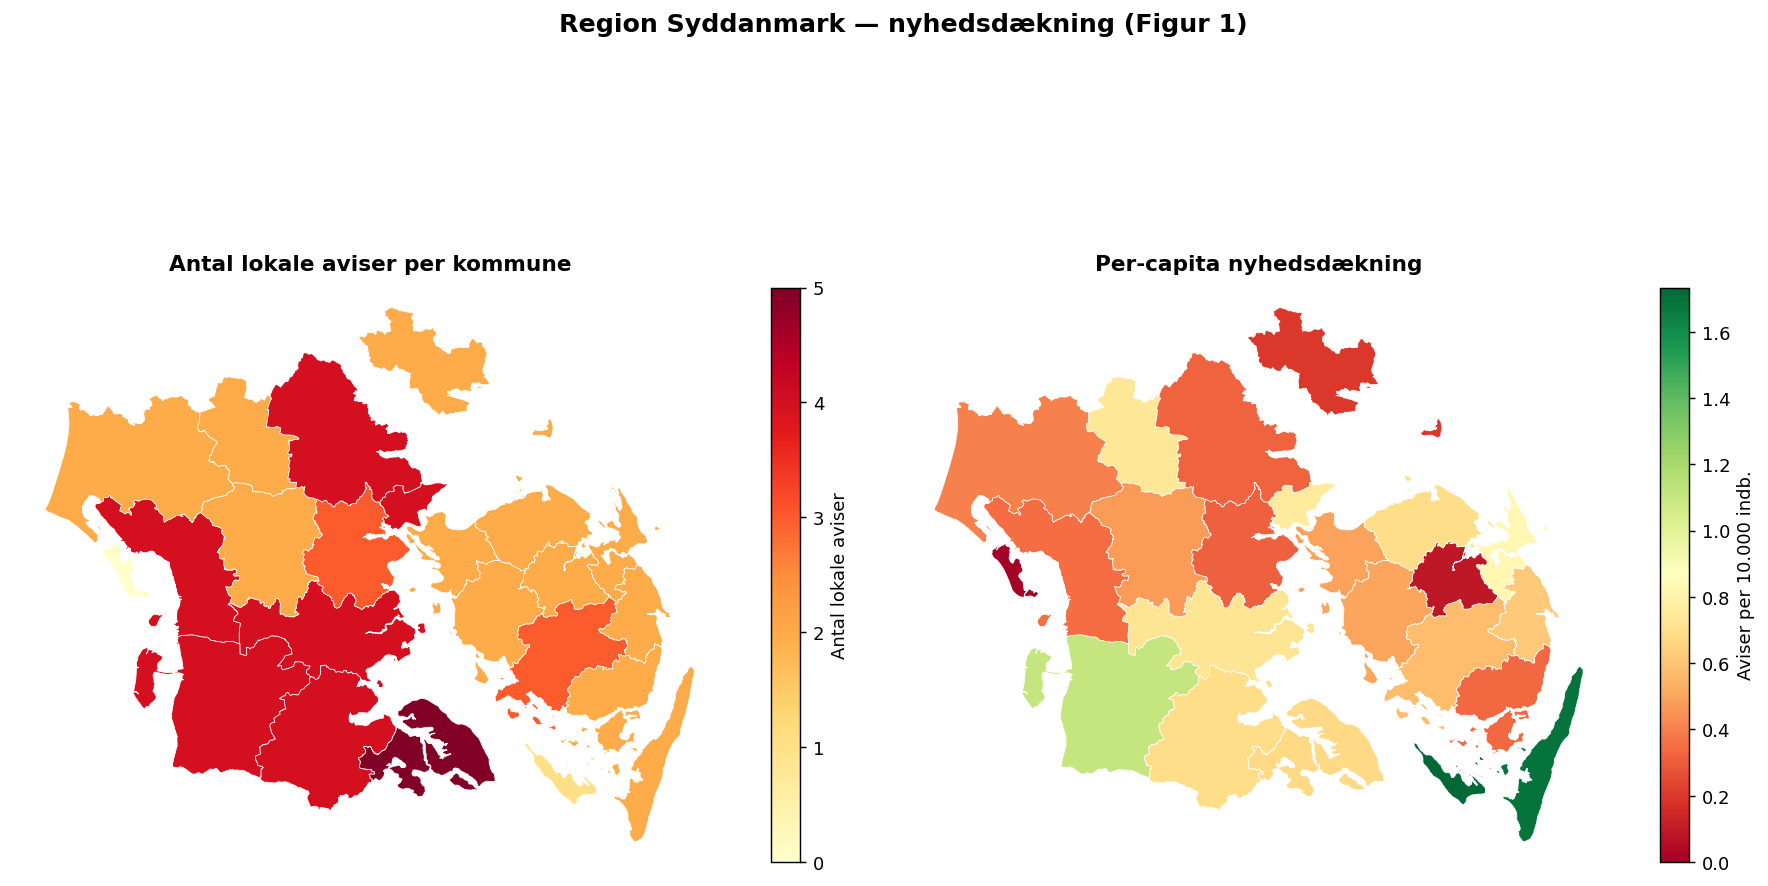

→ Gemt: choropleth_syddanmark.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Venstre: antal aviser
gdf_syd.plot(column="newspaper_count", ax=axes[0], legend=True, cmap="YlOrRd",
             edgecolor="white", linewidth=0.4,
             legend_kwds={"label":"Antal lokale aviser", "shrink":0.6})
axes[0].set_title("Antal lokale aviser per kommune", fontweight="bold")
axes[0].axis("off")

# Højre: per-capita score
gdf_syd.plot(column="score_per_10k", ax=axes[1], legend=True, cmap="RdYlGn",
             edgecolor="white", linewidth=0.4,
             legend_kwds={"label":"Aviser per 10.000 indb.", "shrink":0.6})
axes[1].set_title("Per-capita nyhedsdækning", fontweight="bold")
axes[1].axis("off")

plt.suptitle("Region Syddanmark — nyhedsdækning (Figur 1)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("choropleth_syddanmark.png", dpi=200, bbox_inches="tight")
plt.show()
print("→ Gemt: choropleth_syddanmark.png")

### Figur 2 — binær news desert-klassifikation

Strict definition: `newspaper_count == 0`. Inden for studieområdet matcher kun Fanø
denne definition.

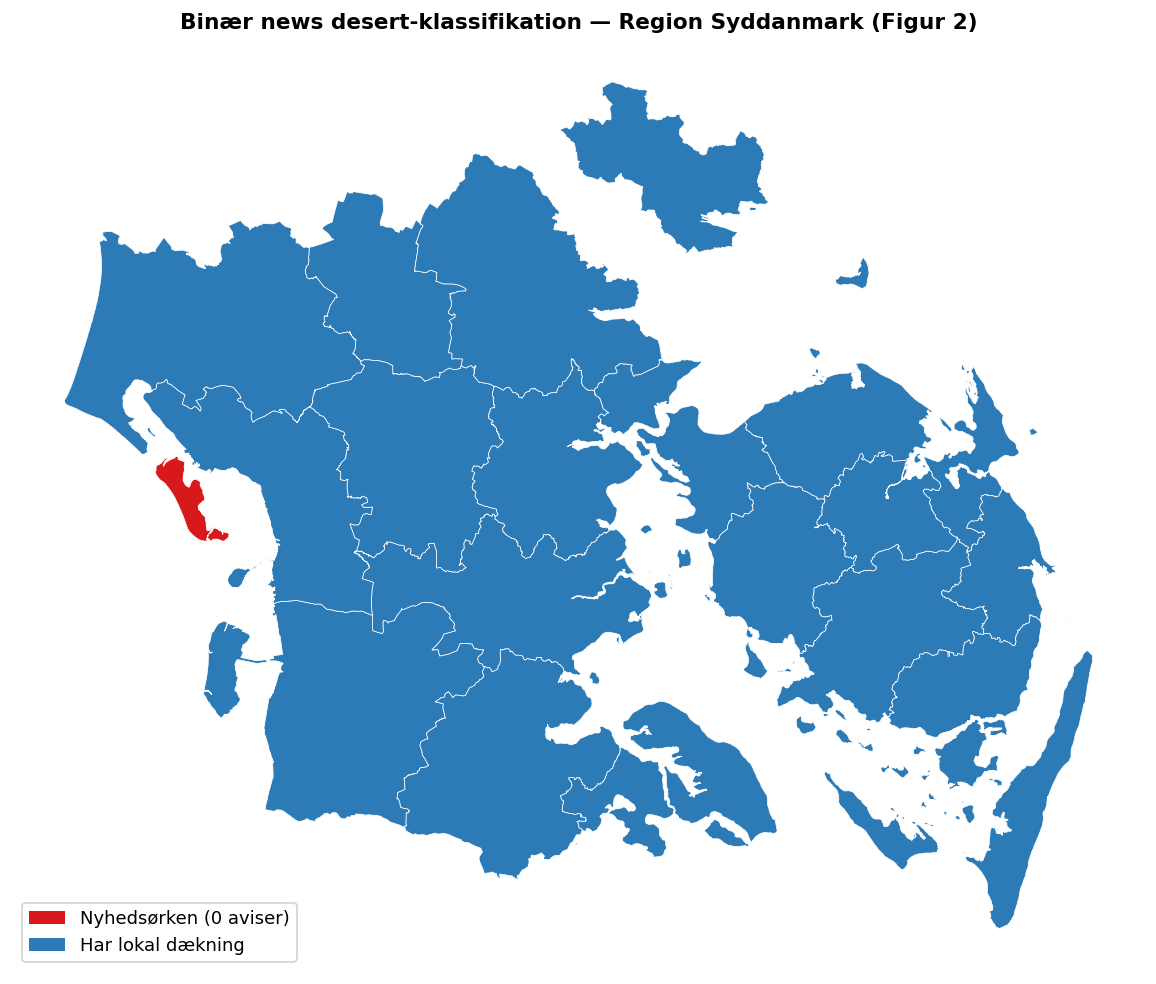

→ Gemt: news_deserts_binary_syd.png


In [9]:
fig, ax = plt.subplots(figsize=(9, 9))
colors = gdf_syd['is_news_desert'].map({True:'#d7191c', False:'#2c7bb6'})
gdf_syd.plot(ax=ax, color=colors, edgecolor='white', linewidth=0.4)
ax.legend(handles=[
    mpatches.Patch(facecolor='#d7191c', label='Nyhedsørken (0 aviser)'),
    mpatches.Patch(facecolor='#2c7bb6', label='Har lokal dækning')
], loc='lower left', fontsize=10)
ax.set_title("Binær news desert-klassifikation — Region Syddanmark (Figur 2)",
             fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig("news_deserts_binary_syd.png", dpi=200, bbox_inches="tight")
plt.show()
print("→ Gemt: news_deserts_binary_syd.png")

## 6. Fordelingsplots

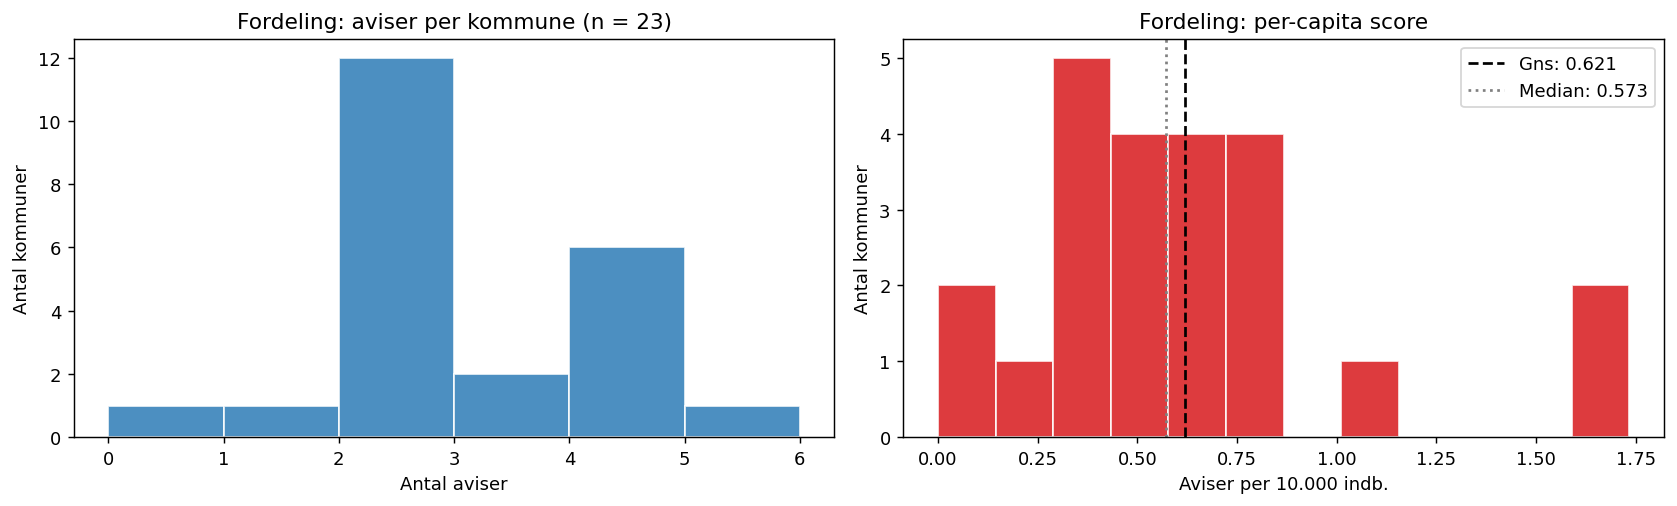

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(syd['newspaper_count'],
             bins=range(0, syd['newspaper_count'].max()+2),
             color='#2c7bb6', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Antal aviser'); axes[0].set_ylabel('Antal kommuner')
axes[0].set_title('Fordeling: aviser per kommune (n = 23)')

axes[1].hist(syd['score_per_10k'], bins=12, color='#d7191c', edgecolor='white', alpha=0.85)
axes[1].axvline(syd['score_per_10k'].mean(), color='black', linestyle='--',
                label=f"Gns: {syd['score_per_10k'].mean():.3f}")
axes[1].axvline(syd['score_per_10k'].median(), color='grey', linestyle=':',
                label=f"Median: {syd['score_per_10k'].median():.3f}")
axes[1].legend()
axes[1].set_xlabel('Aviser per 10.000 indb.'); axes[1].set_ylabel('Antal kommuner')
axes[1].set_title('Fordeling: per-capita score')
plt.tight_layout(); plt.savefig("distribution_syd.png", dpi=200, bbox_inches="tight"); plt.show()

## 7. Spatial autokorrelation — Global Moran's I

Rapporten (§4.3) rapporterer to vægt-specifikationer:

| Vægte | Moran's I | p (999 perm.) |
|---|---|---|
| Queen | −0.012 | 0.394 |
| KNN-4 | +0.098 | 0.123 |

**Vigtigt om KNN-4:** afstande mellem kommuner skal beregnes i en projiceret CRS
(her EPSG:25832, UTM zone 32N — standard for Danmark). Hvis man bruger
`KNN.from_dataframe(gdf, k=4)` direkte på lon/lat-geometri, blander man længde- og
breddegrader (1° lon ≠ 1° lat ved 55°N), og man får en anden naboliste og dermed et
andet I.

In [11]:
y = gdf_syd["score_per_10k"].values

# --- Queen ---
w_queen = Queen.from_dataframe(gdf_syd, use_index=False)
w_queen.transform = "R"
np.random.seed(RANDOM_SEED)
mi_q = Moran(y, w_queen, permutations=999)
print(f"Queen Moran's I = {mi_q.I:+.4f},  p = {mi_q.p_sim:.4f}   (rapport: -0.012, 0.394)")
print(f"  Forventet I  = {mi_q.EI:+.4f}")
print(f"  ⚠ Queen-vægte advarer om islands (Langeland, Ærø, Fanø, Horsens)")

('WARNING: ', 8, ' is an island (no neighbors)')
('WARNING: ', 9, ' is an island (no neighbors)')
('WARNING: ', 15, ' is an island (no neighbors)')
('WARNING: ', 20, ' is an island (no neighbors)')
Queen Moran's I = -0.0115,  p = 0.3920   (rapport: -0.012, 0.394)
  Forventet I  = -0.0455
  ⚠ Queen-vægte advarer om islands (Langeland, Ærø, Fanø, Horsens)


In [12]:
# --- KNN-4 fra projicerede centroider (EPSG:25832) ---
g_proj = gdf_syd.to_crs(25832)
centroids = np.array([(p.x, p.y) for p in g_proj.geometry.centroid])

w_knn = KNN.from_array(centroids, k=4)
w_knn.transform = "R"

np.random.seed(RANDOM_SEED)
mi_k = Moran(y, w_knn, permutations=999)
print(f"KNN-4 Moran's I = {mi_k.I:+.4f},  p = {mi_k.p_sim:.4f}   (rapport: +0.098, 0.123)")
print(f"  Forventet I  = {mi_k.EI:+.4f}")
print(f"  Hver kommune har præcis 4 naboer — ingen islands.")

KNN-4 Moran's I = +0.0982,  p = 0.1060   (rapport: +0.098, 0.123)
  Forventet I  = -0.0455
  Hver kommune har præcis 4 naboer — ingen islands.


## 8. Moran scatterplot (KNN-4)

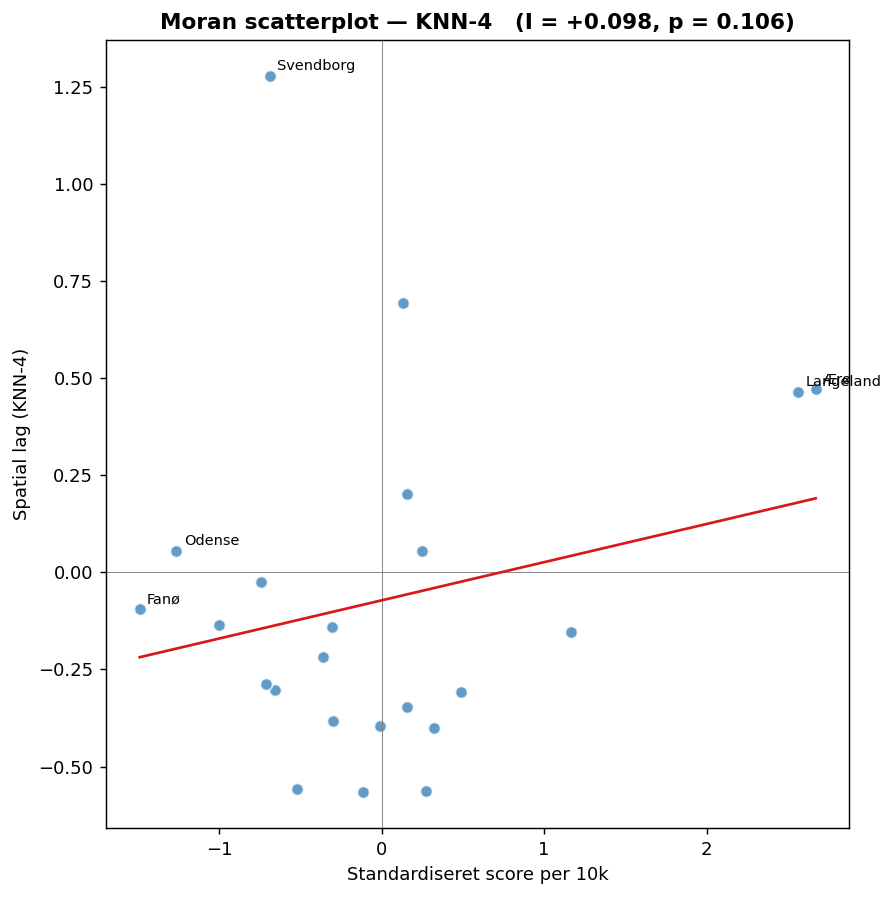

In [13]:
y_std = (y - y.mean()) / y.std()
lag_y_std = w_knn.sparse.dot(y_std)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_std, lag_y_std, s=45, color='#2c7bb6', alpha=0.75, edgecolor='white')
ax.axhline(0, color='grey', lw=0.5); ax.axvline(0, color='grey', lw=0.5)

z = np.polyfit(y_std, lag_y_std, 1)
xs = np.linspace(y_std.min(), y_std.max(), 100)
ax.plot(xs, np.poly1d(z)(xs), color='#d7191c', lw=1.5)

for i, name in enumerate(gdf_syd['kommune_name']):
    if abs(y_std[i]) > 1.2 or abs(lag_y_std[i]) > 1.0:
        ax.annotate(name, (y_std[i], lag_y_std[i]), fontsize=8,
                    xytext=(4,3), textcoords='offset points')

ax.set_xlabel("Standardiseret score per 10k")
ax.set_ylabel("Spatial lag (KNN-4)")
ax.set_title(f"Moran scatterplot — KNN-4   (I = {mi_k.I:+.3f}, p = {mi_k.p_sim:.3f})",
             fontweight='bold')
plt.tight_layout(); plt.savefig("moran_scatter_syd.png", dpi=200, bbox_inches="tight"); plt.show()

## 9. LISA — Local Moran's I (KNN-4)

Rapportens §4.3: af de 23 enheder er **kun Svendborg** signifikant ved p < 0.05
(LISA p ≈ 0.007), klassificeret som Low-High outlier. Bemærk at p-værdier er
permutations-baserede — små udsving over `RANDOM_SEED` er normale.

In [14]:
np.random.seed(RANDOM_SEED)
lisa = Moran_Local(y, w_knn, permutations=999)
gdf_syd["lisa_q"] = lisa.q
gdf_syd["lisa_p"] = lisa.p_sim
gdf_syd["lisa_sig"] = gdf_syd["lisa_p"] < 0.05
gdf_syd["lisa_cluster"] = gdf_syd.apply(
    lambda r: r["lisa_q"] if r["lisa_sig"] else 0, axis=1)

quad_label = {1:"High-High", 2:"Low-High", 3:"Low-Low", 4:"High-Low", 0:"Ikke sig."}
print("── LISA: signifikante kommuner (p < 0.05) ──")
sig = gdf_syd[gdf_syd["lisa_sig"]][["kommune_name","score_per_10k","lisa_q","lisa_p"]]
sig["kvadrant"] = sig["lisa_q"].map(quad_label)
print(sig.to_string(index=False))

print("\n── Tæt-på-signifikante (0.05 ≤ p < 0.11) ──")
near = gdf_syd[(gdf_syd["lisa_p"]>=0.05) & (gdf_syd["lisa_p"]<0.11)]
print(near[["kommune_name","score_per_10k","lisa_p"]].to_string(index=False))

── LISA: signifikante kommuner (p < 0.05) ──
kommune_name  score_per_10k  lisa_q  lisa_p kvadrant
   Svendborg          0.333       2   0.008 Low-High

── Tæt-på-signifikante (0.05 ≤ p < 0.11) ──
   kommune_name  score_per_10k  lisa_p
Faaborg-Midtfyn          0.573   0.090
      Langeland          1.689   0.103
            Ærø          1.734   0.094
        Billund          0.735   0.102
     Sønderborg          0.675   0.085
          Varde          0.404   0.076


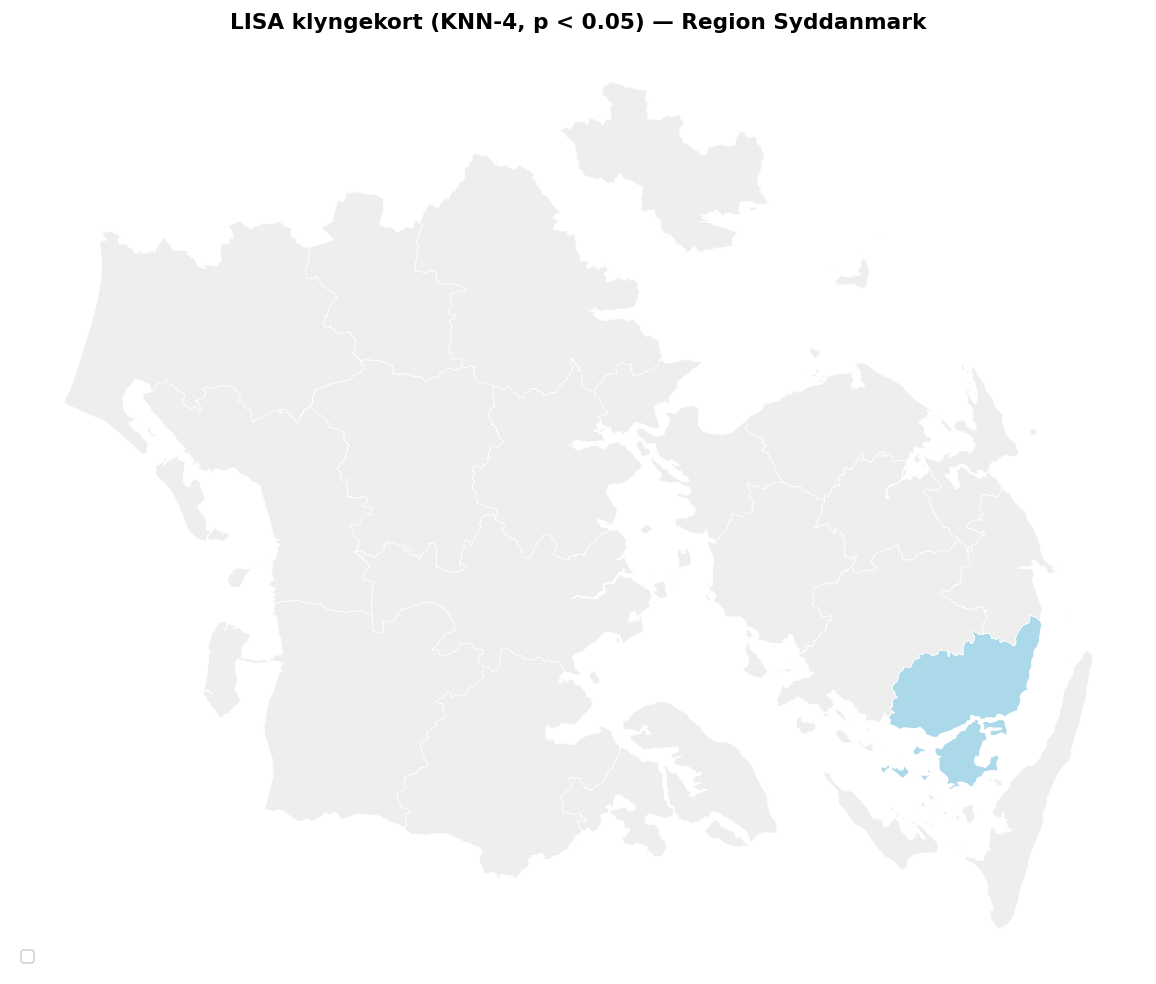

In [15]:
cluster_colors = {1:"#d7191c", 2:"#abd9e9", 3:"#2c7bb6", 4:"#fdae61", 0:"#eeeeee"}

fig, ax = plt.subplots(figsize=(9, 9))
for q_val, color in cluster_colors.items():
    sub = gdf_syd[gdf_syd["lisa_cluster"] == q_val]
    if len(sub) > 0:
        sub.plot(ax=ax, color=color, edgecolor='white', linewidth=0.4,
                 label=f"{quad_label[q_val]} (n={len(sub)})")

ax.legend(loc='lower left', fontsize=9)
ax.set_title("LISA klyngekort (KNN-4, p < 0.05) — Region Syddanmark", fontweight='bold')
ax.axis("off")
plt.tight_layout(); plt.savefig("lisa_clusters_syd.png", dpi=200, bbox_inches="tight"); plt.show()

## 10. Socioøkonomiske korrelationer (Spearman + Pearson)

Forventede Spearman-korrelationer (rapport §4.5, tabel):

| Variabel | Spearman ρ | p | Pearson r | p |
|---|---|---|---|---|
| Mean disposable income | −0.577 | 0.004 | −0.478 | 0.021 |
| Higher-education share | −0.630 | 0.001 | −0.572 | 0.004 |
| Voter turnout (KV21) | +0.265 | 0.222 | +0.270 | 0.212 |

Plus rapportens §4.4: Spearman ρ(population, score) = −0.558, p = 0.006.

In [16]:
socio = pd.read_csv(SOCIO_CSV)
m = syd.merge(socio, on="kommune_kode", how="left")
print(f"Merged with socio: n = {len(m)}")
print(f"Manglende værdier: {m[['avg_income','pct_higher_education','voter_turnout_pct']].isna().sum().to_dict()}")

Merged with socio: n = 23
Manglende værdier: {'avg_income': 0, 'pct_higher_education': 0, 'voter_turnout_pct': 0}


In [17]:
rows = []
for var, label in [("avg_income",            "Mean disposable income (kr)"),
                   ("pct_higher_education",  "Higher-education share (%)"),
                   ("voter_turnout_pct",     "Voter turnout, KV21 (%)")]:
    valid = m[["score_per_10k", var]].dropna()
    rho, p_s = spearmanr(valid["score_per_10k"], valid[var])
    r,   p_p = pearsonr (valid["score_per_10k"], valid[var])
    rows.append({"Variable": label, "Spearman ρ": round(rho,3), "p (S)": round(p_s,3),
                 "Pearson r":  round(r,3),  "p (P)": round(p_p,3),
                 "n": len(valid)})

# Bonus: population
rho_pop, p_pop = spearmanr(m["score_per_10k"], m["population"])
r_pop,   p_pop_pearson = pearsonr(m["score_per_10k"], m["population"])
rows.append({"Variable":"Population (rapport §4.4)",
             "Spearman ρ":round(rho_pop,3), "p (S)":round(p_pop,3),
             "Pearson r":round(r_pop,3),    "p (P)":round(p_pop_pearson,3),
             "n":len(m)})

corr_table = pd.DataFrame(rows)
print(corr_table.to_string(index=False))

                   Variable  Spearman ρ  p (S)  Pearson r  p (P)  n
Mean disposable income (kr)      -0.577  0.004     -0.478  0.021 23
 Higher-education share (%)      -0.630  0.001     -0.572  0.004 23
    Voter turnout, KV21 (%)       0.265  0.222      0.270  0.212 23
  Population (rapport §4.4)      -0.558  0.006     -0.534  0.009 23


## 11. Scatterplots: dækning vs. socioøkonomi

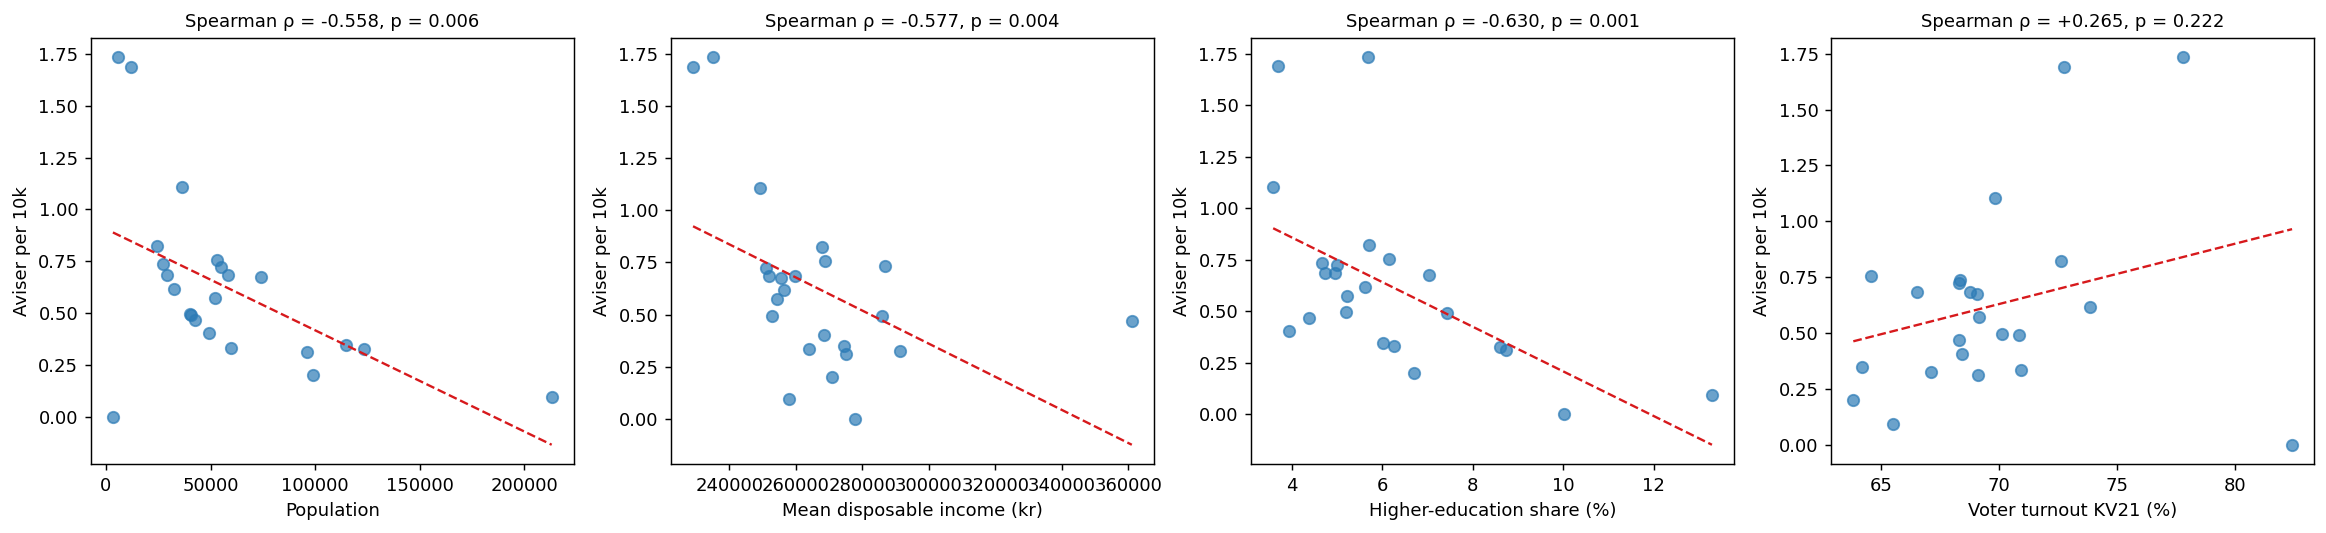

In [18]:
vars_to_plot = [("population",            "Population"),
                ("avg_income",            "Mean disposable income (kr)"),
                ("pct_higher_education",  "Higher-education share (%)"),
                ("voter_turnout_pct",     "Voter turnout KV21 (%)")]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, (var, label) in zip(axes, vars_to_plot):
    valid = m[["score_per_10k", var, "kommune_name"]].dropna()
    ax.scatter(valid[var], valid["score_per_10k"], s=40, alpha=0.7, color='#2c7bb6')
    z = np.polyfit(valid[var], valid["score_per_10k"], 1)
    xs = np.linspace(valid[var].min(), valid[var].max(), 100)
    ax.plot(xs, np.poly1d(z)(xs), '--', color='#d7191c', lw=1.3)

    rho, p_s = spearmanr(valid["score_per_10k"], valid[var])
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel("Aviser per 10k", fontsize=10)
    ax.set_title(f"Spearman ρ = {rho:+.3f}, p = {p_s:.3f}", fontsize=10)
plt.tight_layout(); plt.savefig("correlation_scatter_syd.png", dpi=200, bbox_inches="tight"); plt.show()

## 12. Robusthedstjek: ekskludér Horsens (n = 22)

Rapporten nævner i §4.5 at korrelationerne er kvalitativt uændrede når Horsens
ekskluderes (n = 22, den officielle Region Syddanmark-kommune-tæller):
ρ_income = −0.574 (p = 0.005), ρ_edu = −0.642 (p = 0.001), ρ_turnout = +0.299 (p = 0.176).

In [19]:
m22 = m[m["kommune_name"] != "Horsens"]
print(f"n = {len(m22)} (Horsens ekskluderet)")
for var, label in [("avg_income",            "Income"),
                   ("pct_higher_education",  "Edu"),
                   ("voter_turnout_pct",     "Turnout"),
                   ("population",            "Population")]:
    valid = m22[["score_per_10k", var]].dropna()
    rho, p_s = spearmanr(valid["score_per_10k"], valid[var])
    print(f"  {label:<10s} Spearman ρ = {rho:+.3f}, p = {p_s:.3f}")

n = 22 (Horsens ekskluderet)
  Income     Spearman ρ = -0.574, p = 0.005
  Edu        Spearman ρ = -0.601, p = 0.003
  Turnout    Spearman ρ = +0.188, p = 0.402
  Population Spearman ρ = -0.527, p = 0.012


## 13. Sammenfatning vs. rapport

Hvis tallene ovenfor matcher rapporten ±0.01 (Moran's I) og ±0.05 (permutations-baserede
p-værdier), så reproducerer denne notebook hele §4–§4.5 fra `news_deserts_full.tex`.

Næste skridt:
- [ ] Verificér at `socioeconomic_data.csv` præcist matcher tabellerne brugt i rapporten
  (INDKP101 år, HFUDD10 år, KV21-leverandør)
- [ ] Hvis der er afvigelser i KNN-4 p-værdien, prøv at variere `RANDOM_SEED` —
  det globale I er deterministisk, men p_sim er permutations-baseret